# Introduction
Exploration of the data FR and ENG


# LIBRARIES

In [50]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy
from sklearn.feature_extraction.text import CountVectorizer
import os
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm

In [2]:
fr_data = open("../data/small_vocab_fr.txt", "r").readlines()
en_data = open("../data/small_vocab_en.txt", "r").readlines()

fr_data = [line.strip() for line in fr_data if line.strip()]
en_data = [line.strip() for line in en_data if line.strip()]

In [3]:
i = 55
print(fr_data[i])
print(en_data[i])

l'orange est la moins aimé des fruits , mais le pamplemousse est leur moins aimé .
the orange is her least liked fruit , but the grapefruit is their least liked .


In [4]:
print(fr_data[0])
print(word_tokenize(fr_data[0], language="french", preserve_line=True))

new jersey est parfois calme pendant l' automne , et il est neigeux en avril .
['new', 'jersey', 'est', 'parfois', 'calme', 'pendant', 'l', "'", 'automne', ',', 'et', 'il', 'est', 'neigeux', 'en', 'avril', '.']


In [5]:
# BOW
tokens = word_tokenize(fr_data[0], language="french", preserve_line=True)
bow_simple = Counter(tokens)

# Print the 10 most common tokens
print(bow_simple.most_common(10))

[('est', 2), ('new', 1), ('jersey', 1), ('parfois', 1), ('calme', 1), ('pendant', 1), ('l', 1), ("'", 1), ('automne', 1), (',', 1)]


**NOW THAT WE SEE THAT IT'S WORKING, WE NOW CREAT A WAY TO PROCESS THE DATA IN ONE STREAM**  
The process will be as follows:
1. Tokenization
2. Stopword removal
3. Lemmatization
4. BOW creation

In [6]:
# Charger les modèles une seule fois
nlp_dict = {
    "french": spacy.load("fr_core_news_sm"),
    "english": spacy.load("en_core_web_sm"),
}

# "l" n'est pas dans la liste des stop words donc je vais l'ajouter manuellement
custom_stopwords = {"l"}

def process_text_spacy(text, lang="french"):
    doc = nlp_dict[lang](text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and token.text.lower() not in custom_stopwords
    ]
    return tokens


print(process_text_spacy(fr_data[0], lang="french"))
print(process_text_spacy(en_data[0], lang="english"))

['new', 'jersey', 'calme', 'automne', 'neigeux', 'avril']
['new', 'jersey', 'quiet', 'autumn', 'snowy', 'april']


In [7]:
## THIS IS SLOW AF
# from tqdm import tqdm

# # Preprocess les phrases en affichant une barre de progression
# fr_processed = [" ".join(process_text_spacy(text)) for text in tqdm(fr_data, desc="Prétraitement FR")]

# # Initialiser le vectorizer
# vectorizer = CountVectorizer()

# # Fit sur les données prétraitées
# vectorizer.fit(fr_processed)

# # Afficher le vocabulaire appris
# print(vectorizer.get_feature_names_out())

In [ ]:
# 1) Charger spaCy (on garde le tagger/lemmatizer ; on coupe parser/NER)
nlp_fr = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

# Stopwords personnalisés (ex: "l", "d", "j" pour les contractions)
custom_stops = {"l", "d", "j"}
stop_fr = set(nlp_fr.Defaults.stop_words) | custom_stops

def doc_to_clean_text(doc):
    # lemmatise, met en minuscule, retire stopwords & ponctuation & espaces
    toks = [
        t.lemma_.lower()
        for t in doc
        if not t.is_punct and not t.is_space and t.text.lower() not in stop_fr
    ]
    return " ".join(toks)

# 2) Prétraitement PARALLÉLISÉ avec nlp.pipe
n_workers = max(os.cpu_count() - 1, 1)  # ajuste selon ta machine
batch_size = 512                         # ajuste selon RAM/taille des phrases

fr_processed = []
for doc in tqdm(
    nlp_fr.pipe(fr_data, batch_size=batch_size, n_process=n_workers),
    total=len(fr_data),
    desc="Prétraitement FR (spaCy, parallèle)"
):
    fr_processed.append(doc_to_clean_text(doc))

# Sauvegarder fr_processed dans un fichier texte
with open("fr_processed.txt", "w", encoding="utf-8") as f:
    for line in fr_processed:
        f.write(line + "\n")

print("fr_processed sauvegardé dans fr_processed.txt")

# 3) Vectorisation BoW
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(fr_processed)

print("Taille vocabulaire :", len(vectorizer.get_feature_names_out()))
print("Shape matrice BoW :", X.shape)


Prétraitement FR (spaCy, parallèle): 100%|██████████| 137860/137860 [05:19<00:00, 431.77it/s]


✅ fr_processed sauvegardé dans fr_processed.txt
Taille vocabulaire : 190
Shape matrice BoW : (137860, 190)


In [25]:
# TOP WORDS
top_n = 50
word_counts = X.sum(axis=0)
top_words = word_counts.argsort()[0, -top_n:][::-1]
for i in top_words:
    print(vectorizer.get_feature_names_out()[i], ":", word_counts[0, i])

[['pluvieux' 'humide' 'relaxer' 'doux' 'occuper' 'merveilleux' 'août'
  'sec' 'octobre' 'février' 'décembre' 'novembre' 'avril' 'juillet'
  'septembre' 'mai' 'mars' 'hiver' 'janvier' 'printemps' 'juin'
  'pamplemousse' 'raisin' 'mangue' 'pomme' 'banane' 'fraise' 'orange'
  'poire' 'pêche' 'chine' 'new' 'jersey' 'france' 'inde' 'états' 'unis'
  'pari' 'mois' 'chaud' 'citron' 'froid' 'agréable' 'automne' 'aimé'
  'préférer' 'aimer' 'fruit' 'généralement' 'jamais']] : [[ 7658  8446  8458  8472  8618  8704  8789  8794  8911  8942  8945  8951
   8954  8956  8958  8995  9022  9038  9090  9100  9133 10620 10632 10673
  10692 10692 10692 10692 10692 10692 10936 11047 11052 11170 11172 11267
  11270 11334 14350 16405 16527 16794 17751 18138 20393 20929 25629 27192
  31292 37215]]


In [ ]:
# Convert BoW matrix to a DataFrame (MEME CHOSE POUR BOW SI ON VEUT COMPARER)
df_bow = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

,agréable,aimer,aimon,aimé,aller,allez,allier,allée,amusant,anglais,...,volant,vouloir,vous,école,éléphant,élépher,épicerie,états,été,être
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


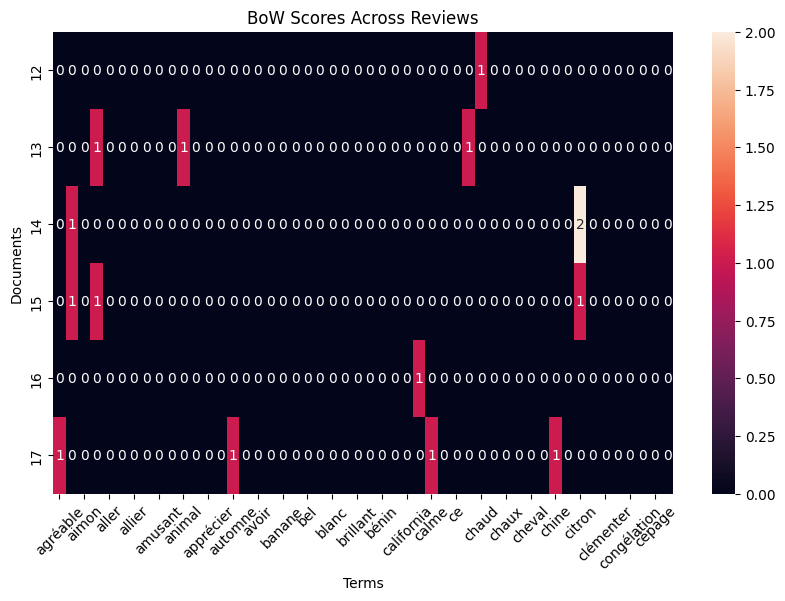

In [23]:
# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_bow.iloc[12:18, :50], annot=True)
plt.title("BoW Scores Across Reviews")
plt.xlabel("Terms")
plt.xticks(rotation=45)
plt.ylabel("Documents")
plt.show()

In [30]:
vectorizer.get_feature_names_out()[top_words].shape

(1, 25)

In [44]:
word_counts[0, top_words][0]

matrix([[10692, 10692, 10692, 10692, 10692, 10936, 11047, 11052, 11170,
         11172, 11267, 11270, 11334, 14350, 16405, 16527, 16794, 17751,
         18138, 20393, 20929, 25629, 27192, 31292, 37215]])

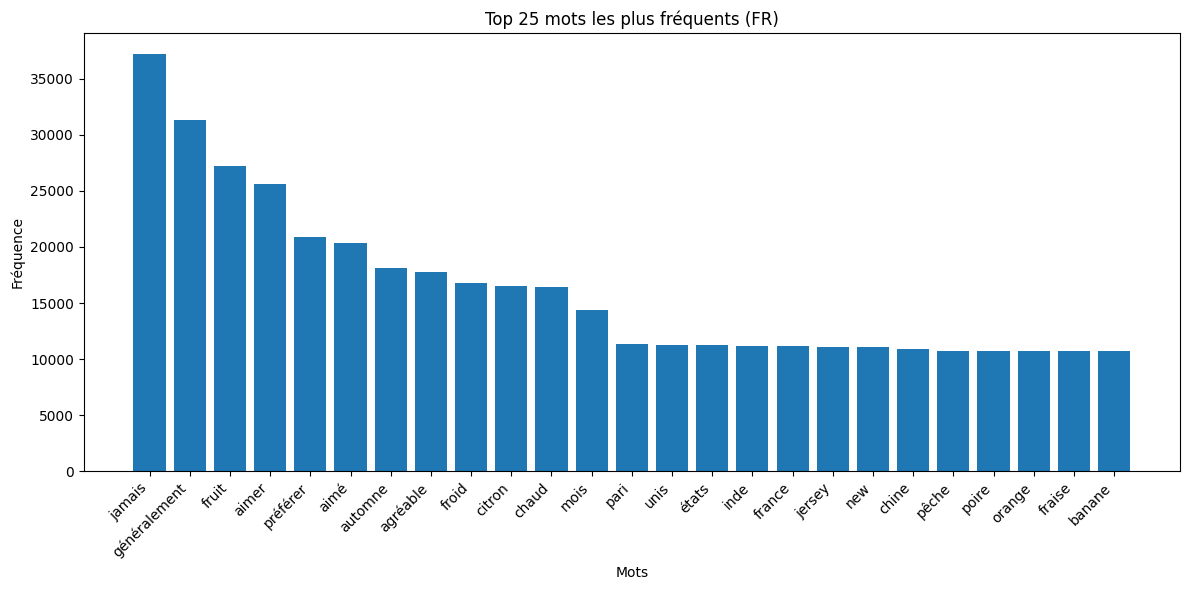

In [49]:
# Récupérer les mots du vocabulaire
words = vectorizer.get_feature_names_out()

# Somme des occurrences de chaque mot
word_counts = X.sum(axis=0).A1  # .A1 pour convertir en array numpy 1D

# Trier et garder les top_n
top_n = 25
sorted_idx = np.argsort(word_counts)[-top_n:][::-1]  # indices triés
top_words = words[sorted_idx]
top_counts = word_counts[sorted_idx]

# Tracer un bar plot
plt.figure(figsize=(12, 6))
plt.bar(top_words, top_counts)
plt.xticks(rotation=45, ha="right")
plt.title(f"Top {top_n} mots les plus fréquents (FR)")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()


## TRAITEMENT DES TEXTES EN ANGLAIS

In [51]:
en_processed = []
nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])
for doc in tqdm(
    nlp_en.pipe(en_data, batch_size=batch_size, n_process=n_workers),
    total=len(en_data),
    desc="Prétraitement EN (spaCy, parallèle)"
):
    en_processed.append(doc_to_clean_text(doc))

# Sauvegarder en_processed dans un fichier texte
with open("en_processed.txt", "w", encoding="utf-8") as f:
    for line in en_processed:
        f.write(line + "\n")

print("en_processed sauvegardé dans en_processed.txt")

Prétraitement EN (spaCy, parallèle): 100%|██████████| 137860/137860 [05:18<00:00, 432.21it/s]


en_processed sauvegardé dans en_processed.txt


In [53]:
# 3) Vectorisation BoW
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(en_processed)

print("Taille vocabulaire :", len(vectorizer.get_feature_names_out()))
print("Shape matrice BoW :", X.shape)


Taille vocabulaire : 151
Shape matrice BoW : (137860, 151)


In [54]:
# TOP WORDS
top_n = 50
word_counts = X.sum(axis=0)
top_words = word_counts.argsort()[0, -top_n:][::-1]
for i in top_words:
    print(vectorizer.get_feature_names_out()[i], ":", word_counts[0, i])

# Convert BoW matrix to a DataFrame (MEME CHOSE POUR BOW SI ON VEUT COMPARER)
df_en_bow = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

[['nice' 'may' 'autumn' 'march' 'winter' 'january' 'spring' 'june' 'fall'
  'his' 'my' 'your' 'peach' 'strawberry' 'pear' 'mango' 'lemon' 'lime'
  'grapefruit' 'banana' 'apple' 'grape' 'orange' 'he' 'china' 'france'
  'jersey' 'california' 'united' 'states' 'india' 'paris' 'new' 'dislike'
  'she' 'most' 'like' 'fruit' 'least' 'favorite' 'never' 'usually'
  'sometimes' 'and' 'but' 'the' 'during' 'it' 'in' 'be']] : [[  8984   8995   9004   9023   9038   9090   9102   9133   9134   9700
    9700   9734  10692  10692  10692  10692  10692  10692  10692  10692
   10692  10692  10692  10786  10953  11170  11225  11250  11270  11270
   11277  11334  12197  12406  14138  14934  25948  27192  27564  28332
   37500  37507  37746  59850  63987  67628  74933  75377  75525 209339]]


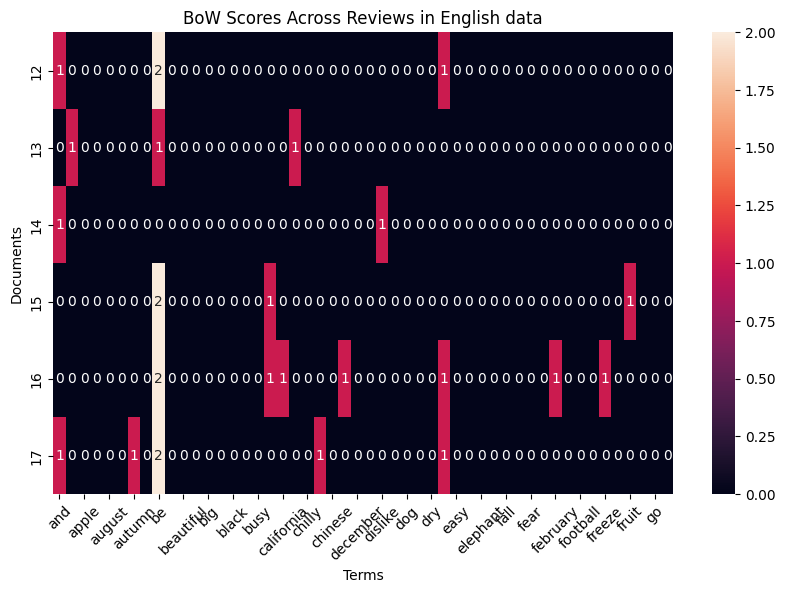

In [ ]:
# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_en_bow.iloc[12:18, :50], annot=True)
plt.title("BoW Scores Across Reviews in English data")
plt.xlabel("Terms")
plt.xticks(rotation=45)
plt.ylabel("Documents")

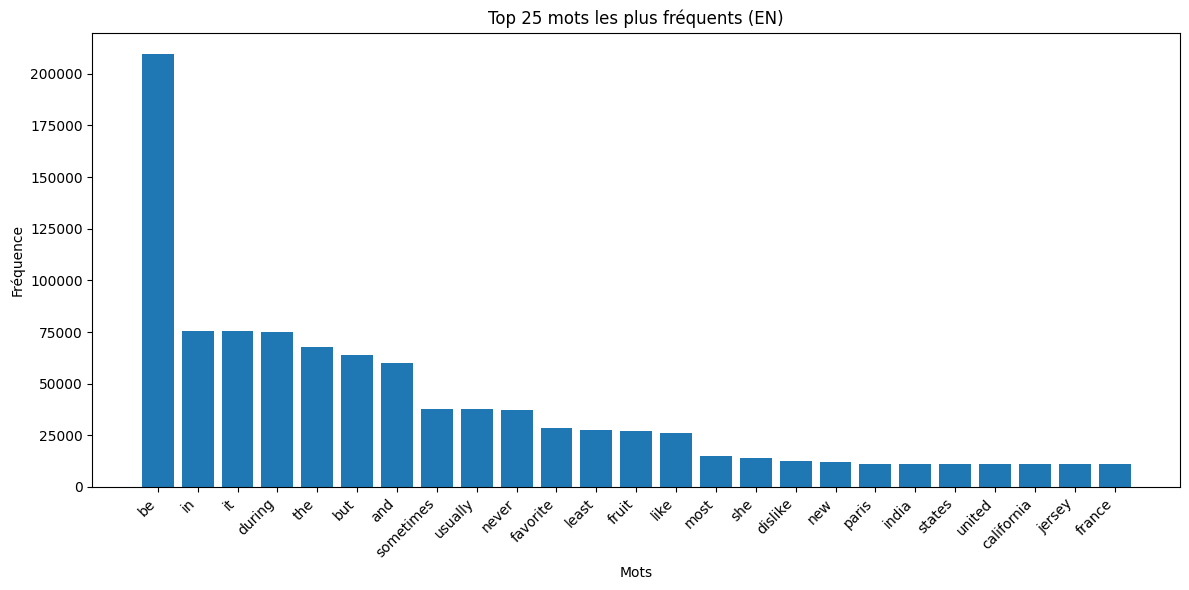

In [56]:
# Récupérer les mots du vocabulaire
words = vectorizer.get_feature_names_out()

# Somme des occurrences de chaque mot
word_counts = X.sum(axis=0).A1  # .A1 pour convertir en array numpy 1D

# Trier et garder les top_n
top_n = 25
sorted_idx = np.argsort(word_counts)[-top_n:][::-1]  # indices triés
top_words = words[sorted_idx]
top_counts = word_counts[sorted_idx]

# Tracer un bar plot
plt.figure(figsize=(12, 6))
plt.bar(top_words, top_counts)
plt.xticks(rotation=45, ha="right")
plt.title(f"Top {top_n} mots les plus fréquents (EN)")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()


# DIRECTLY WORKING ON THE PROCESS DATA

In [1]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy
from sklearn.feature_extraction.text import CountVectorizer
import os
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
from wordcloud import WordCloud

In [2]:
fr_processed = open("../data/processed/fr_processed.txt", "r").readlines()
en_processed = open("../data/processed/en_processed.txt", "r").readlines()

fr_data = [line.strip() for line in fr_processed if line.strip()]
en_data = [line.strip() for line in en_processed if line.strip()]

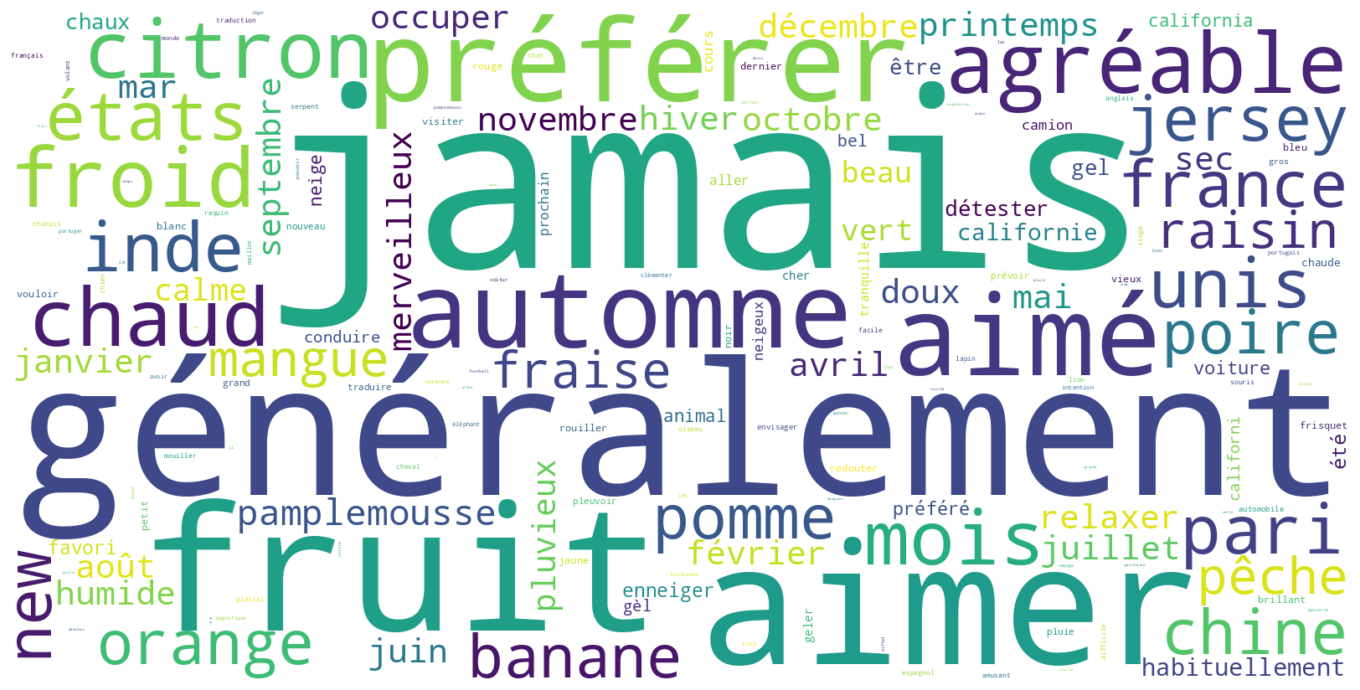

In [3]:
text_all = " ".join(fr_processed)

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    collocations=False,
    random_state=42
).generate(text_all)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()

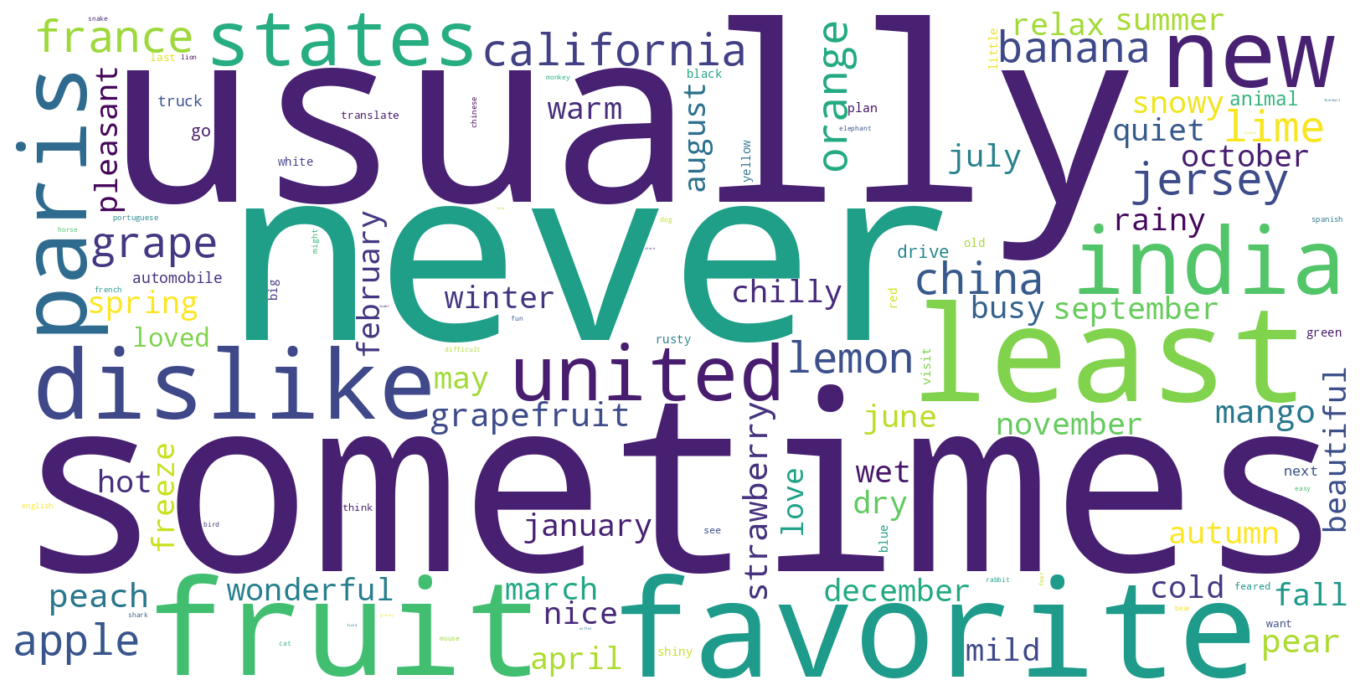

In [4]:
text_all = " ".join(en_processed)

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    collocations=False,
    random_state=42
).generate(text_all)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()

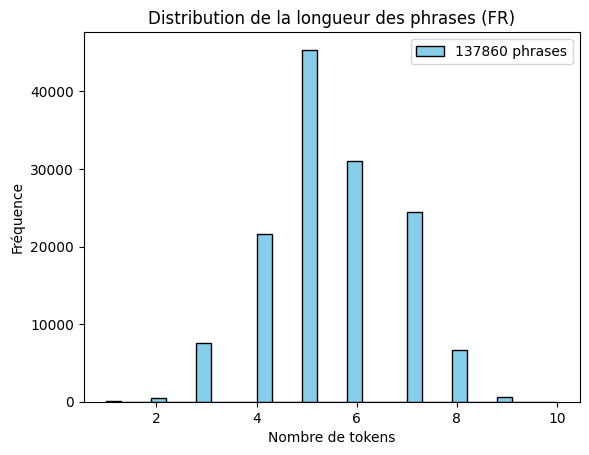

In [7]:
lengths = [len(doc.split()) for doc in fr_processed]

plt.hist(lengths, bins=30, color="skyblue", edgecolor="black", label=f"{len(fr_processed)} phrases")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des phrases (FR)")
plt.legend()

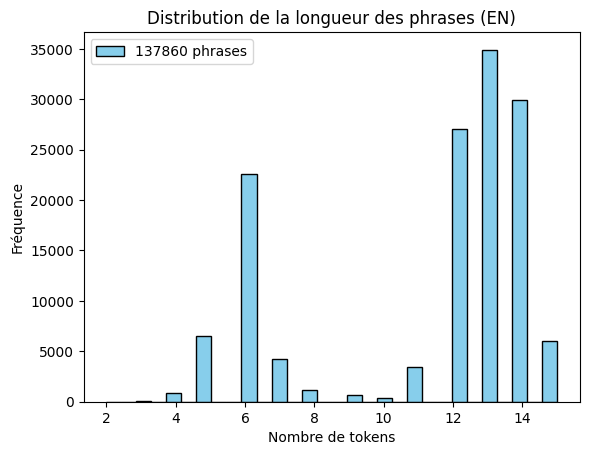

In [21]:
lengths = [len(doc.split()) for doc in en_processed]

plt.hist(lengths, bins=30, color="skyblue", edgecolor="black", label=f"{len(en_processed)} phrases")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des phrases (EN)")
plt.legend()

Text(0.5, 1.0, 'Comparaison longueurs FR vs EN')

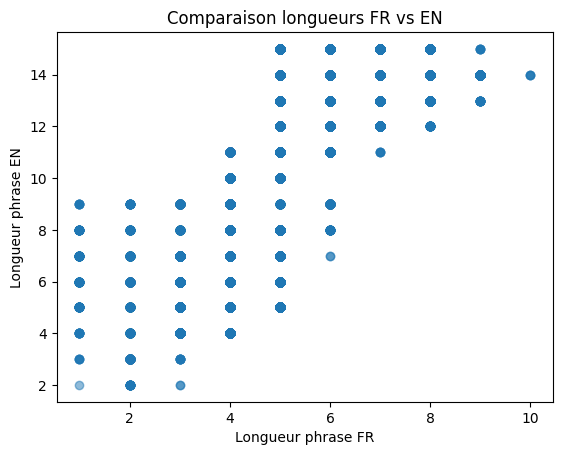

In [9]:
lengths_fr = [len(doc.split()) for doc in fr_processed]
lengths_en = [len(doc.split()) for doc in en_processed]

plt.scatter(lengths_fr, lengths_en, alpha=0.5)
plt.xlabel("Longueur phrase FR")
plt.ylabel("Longueur phrase EN")
plt.title("Comparaison longueurs FR vs EN")

In [10]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(fr_processed)

print("Top bigrammes :", bigram_vectorizer.get_feature_names_out())

Top bigrammes : ['aimer citron' 'chine jamais' 'citron vert' 'fruit aimer' 'fruit aimé'
 'fruit préférer' 'généralement agréable' 'généralement chaud'
 'généralement froid' 'inde jamais' 'jamais agréable' 'jamais chaud'
 'jamais froid' 'jersey jamais' 'mois août' 'mois mai' 'new jersey'
 'pari jamais' 'unis jamais' 'états unis']


In [11]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(en_processed)

print("Top bigrammes :", bigram_vectorizer.get_feature_names_out())

Top bigrammes : ['and it' 'be never' 'be sometimes' 'be the' 'be usually' 'but it'
 'but the' 'california be' 'favorite fruit' 'fruit be' 'fruit but'
 'india be' 'it be' 'least favorite' 'least like' 'new jersey' 'paris be'
 'states be' 'the united' 'united states']


In [13]:
all_tokens = " ".join(fr_processed).split()
freq_dict = Counter(all_tokens)

print(freq_dict.most_common(10))  # top 10 mots

[('jamais', 37215), ('généralement', 31292), ('fruit', 27192), ('aimer', 25629), ('préférer', 20929), ('aimé', 20393), ('automne', 18138), ('agréable', 17751), ('froid', 16794), ('citron', 16527)]


In [14]:
# fr_processed est une liste de listes de tokens
all_tokens = [tok for sentence in fr_processed for tok in sentence]
freq_dict = Counter(all_tokens)

print(freq_dict.most_common(10))

[('e', 622900), (' ', 614838), ('r', 483382), ('a', 451544), ('i', 416992), ('n', 294931), ('m', 291708), ('t', 213051), ('u', 204799), ('o', 200266)]


Text(0, 0.5, 'Fréquence (log)')

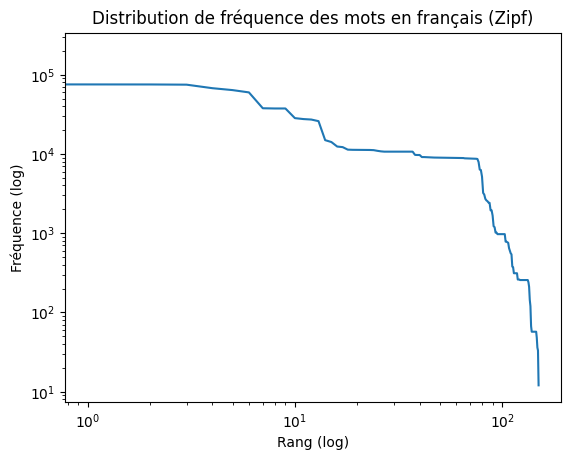

In [19]:
freqs_sorted = np.array(sorted(freq_dict.values(), reverse=True))

plt.plot(freqs_sorted)
plt.xscale("log")
plt.yscale("log")
plt.title("Distribution de fréquence des mots en français (Zipf)")
plt.xlabel("Rang (log)")
plt.ylabel("Fréquence (log)")

Text(0, 0.5, 'Fréquence (log)')

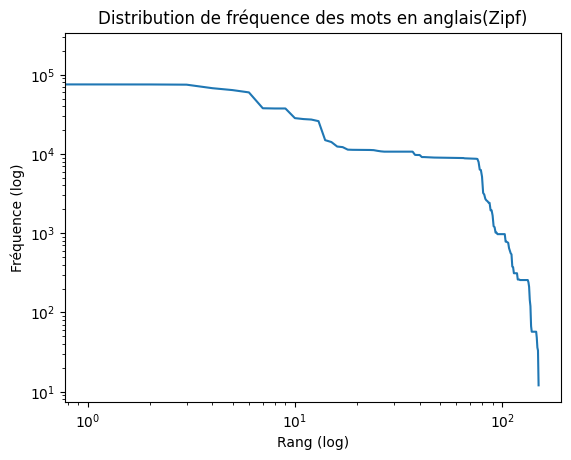

In [20]:
# English
all_tokens = " ".join(en_processed).split()
freq_dict = Counter(all_tokens)

freqs_sorted = np.array(sorted(freq_dict.values(), reverse=True))

plt.plot(freqs_sorted)
plt.xscale("log")
plt.yscale("log")
plt.title("Distribution de fréquence des mots en anglais(Zipf)")
plt.xlabel("Rang (log)")
plt.ylabel("Fréquence (log)")